# Kalshi Bid-Ask Spread Analysis

Loads the Kalshi candle data, computes the daily bid-ask spread for each contract and the number of days until the corresponding Fed decision, and produces a clean dataset for further analysis.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

os.makedirs("../Figures", exist_ok=True)

# ── Load raw Kalshi candle data ──────────────────────────────────────────────
df_raw = pd.read_csv("../Data/Kalshi/Kalshi_rates.csv")

# ── Derived columns ──────────────────────────────────────────────────────────
df_raw["spread"] = df_raw["yes_ask_close"] - df_raw["yes_bid_close"]

# days_to_decision: positive = observation is BEFORE the decision
df_raw["days_to_decision"] = (df_raw["market_close_ts"] - df_raw["candle_ts"]) / 86_400

# Extract clean ticker suffix (H0, C25, H25, H50, TC25, …) for labelling
df_raw["contract_type"] = df_raw["ticker"].str.extract(r"-([A-Z]+\d*)$")

# ── Filter to usable rows ────────────────────────────────────────────────────
# Keep rows where both bid and ask are non-null and non-negative,
# horizon is 0–120 days (covers the full active-trading period for any Fed market)
df_clean = (
    df_raw
    .dropna(subset=["spread", "yes_bid_close", "yes_ask_close"])
    .query("0 <= days_to_decision <= 120 and spread >= 0")
    .copy()
)

print(f"Raw rows         : {len(df_raw):,}")
print(f"Clean rows       : {len(df_clean):,}")
print(f"Unique decisions : {df_clean['decision_key'].nunique()}")
print(f"Days-to-decision : {df_clean['days_to_decision'].min():.1f} – {df_clean['days_to_decision'].max():.1f}")
print(f"\nSpread summary (dollars):")
print(df_clean["spread"].describe().round(4))

Raw rows         : 16,857
Clean rows       : 5,568
Unique decisions : 26
Days-to-decision : 0.6 – 119.6

Spread summary (dollars):
count    5568.0000
mean        0.0301
std         0.0727
min         0.0100
25%         0.0100
50%         0.0100
75%         0.0300
max         0.9900
Name: spread, dtype: float64


## Spread vs Days-to-Decision

Scatter plot of every observation, overlaid with the binned median (10-day bins) and interquartile range, coloured by contract type.

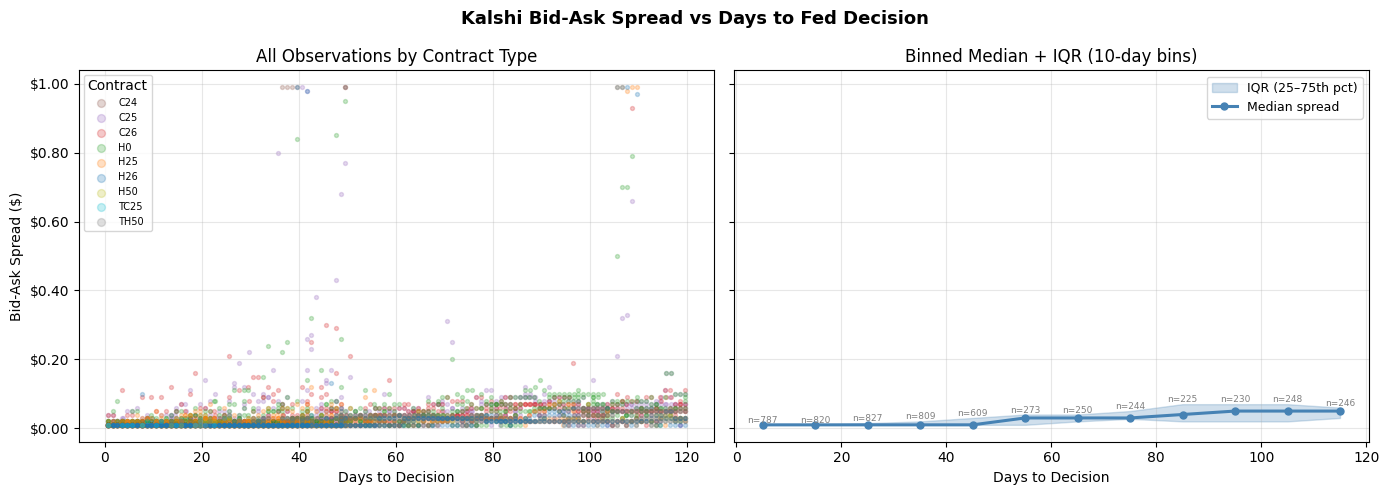

Figure saved to Figures/kalshi_spread_vs_dtd.png


In [2]:
# ── Bin by days_to_decision (10-day bins) ───────────────────────────────────
BIN_WIDTH = 10
bins = np.arange(0, df_clean["days_to_decision"].max() + BIN_WIDTH, BIN_WIDTH)
df_clean["dtd_bin"] = pd.cut(df_clean["days_to_decision"], bins=bins)

binned = (
    df_clean.groupby("dtd_bin", observed=True)["spread"]
    .agg(median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75), n="count")
    .reset_index()
)
binned["bin_mid"] = binned["dtd_bin"].apply(lambda x: x.mid)

# ── Figure: two panels ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Kalshi Bid-Ask Spread vs Days to Fed Decision", fontsize=13, fontweight="bold")

# colour palette by contract type
ctypes = df_clean["contract_type"].unique()
palette = plt.cm.tab10(np.linspace(0, 1, len(ctypes)))
cmap = dict(zip(ctypes, palette))

# ── Left panel: scatter coloured by contract type ────────────────────────────
ax = axes[0]
for ct, grp in df_clean.groupby("contract_type"):
    ax.scatter(
        grp["days_to_decision"], grp["spread"],
        color=cmap[ct], alpha=0.25, s=8, label=ct, rasterized=True
    )
ax.set_xlabel("Days to Decision")
ax.set_ylabel("Bid-Ask Spread ($)")
ax.set_title("All Observations by Contract Type")
ax.legend(title="Contract", fontsize=7, markerscale=2, loc="upper left")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.2f"))
ax.grid(True, alpha=0.3)

# ── Right panel: binned median + IQR ─────────────────────────────────────────
ax2 = axes[1]
ax2.fill_between(
    binned["bin_mid"], binned["q25"], binned["q75"],
    alpha=0.25, color="steelblue", label="IQR (25–75th pct)"
)
ax2.plot(
    binned["bin_mid"], binned["median"],
    color="steelblue", linewidth=2.2, marker="o", markersize=5, label="Median spread"
)
# Annotate count per bin
for _, row in binned.iterrows():
    if row["n"] >= 5:
        ax2.annotate(
            f"n={row['n']}", xy=(row["bin_mid"], row["q75"]),
            fontsize=6.5, ha="center", va="bottom", color="grey"
        )
ax2.set_xlabel("Days to Decision")
ax2.set_title("Binned Median + IQR (10-day bins)")
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.2f"))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../Figures/kalshi_spread_vs_dtd.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to Figures/kalshi_spread_vs_dtd.png")

## Three Simple Spread Rules

Threshold breakpoints are computed empirically from the binned medians above.
The three zones correspond to:
1. **Far** (> 45 days): wide spreads, thin order book, market still forming
2. **Mid** (15–45 days): active trading window, moderate spreads
3. **Near** (≤ 15 days): approaching resolution, narrowest spreads

=== Kalshi Bid-Ask Spread: 3 Simple Rules ===

Rule 1  days >  45         → spread ≈ $0.04  (far,  thin book)
Rule 2  15 < days ≤ 45  → spread ≈ $0.01  (mid,  active)
Rule 3  days ≤  15         → spread ≈ $0.01  (near, approaching resolution)


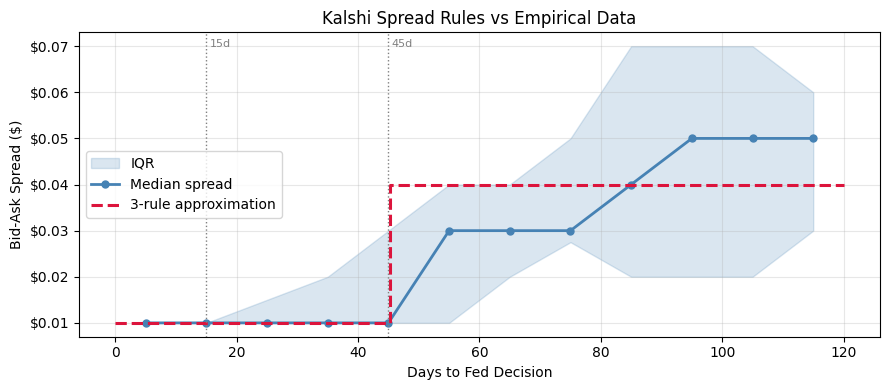

Figure saved to Figures/kalshi_spread_rules.png


In [3]:
# ── Derive thresholds from the binned medians ────────────────────────────────
# Threshold breakpoints (days_to_decision)
T_FAR  = 45   # days: far zone  → days > T_FAR
T_MID  = 15   # days: mid zone  → T_MID < days <= T_FAR
               #       near zone → days <= T_MID

# Empirical median spread per zone (computed live from binned data)
far_spread  = binned.loc[binned["bin_mid"] >  T_FAR, "median"].median()
mid_spread  = binned.loc[(binned["bin_mid"] > T_MID) & (binned["bin_mid"] <= T_FAR), "median"].median()
near_spread = binned.loc[binned["bin_mid"] <= T_MID, "median"].median()

# Round to nearest $0.01 (Kalshi minimum tick)
far_spread  = round(far_spread,  2)
mid_spread  = round(mid_spread,  2)
near_spread = round(near_spread, 2)

print("=== Kalshi Bid-Ask Spread: 3 Simple Rules ===\n")
print(f"Rule 1  days > {T_FAR:>3}         → spread ≈ ${far_spread:.2f}  (far,  thin book)")
print(f"Rule 2  {T_MID} < days ≤ {T_FAR}  → spread ≈ ${mid_spread:.2f}  (mid,  active)")
print(f"Rule 3  days ≤ {T_MID:>3}         → spread ≈ ${near_spread:.2f}  (near, approaching resolution)")

# ── Function ─────────────────────────────────────────────────────────────────
def kalshi_typical_spread(days_to_decision: float) -> float:
    """
    Return the typical Kalshi bid-ask spread (in dollars) for a Fed-decision
    contract, given how many calendar days remain until the decision.

    Rules derived from empirical medians across all Kalshi Fed-rate contracts:
      - days > 45  → wide spread (thin order book, early-market)
      - 15 < days <= 45 → moderate spread (active trading window)
      - days <= 15 → narrow spread (approaching resolution)

    Args:
        days_to_decision: calendar days remaining until the Fed decision.

    Returns:
        Typical full bid-ask spread in USD (use spread/2 for half-spread cost).
    """
    if days_to_decision > T_FAR:
        return far_spread
    elif days_to_decision > T_MID:
        return mid_spread
    else:
        return near_spread


# ── Visualise the rule step function over the binned data ────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(binned["bin_mid"], binned["q25"], binned["q75"],
                alpha=0.20, color="steelblue", label="IQR")
ax.plot(binned["bin_mid"], binned["median"],
        color="steelblue", lw=2, marker="o", ms=5, label="Median spread")

dtd_range = np.linspace(0, 120, 500)
rule_line = [kalshi_typical_spread(d) for d in dtd_range]
ax.step(dtd_range, rule_line, color="crimson", lw=2.2, where="post",
        label="3-rule approximation", linestyle="--")

for threshold, label in [(T_FAR, f"45d"), (T_MID, f"15d")]:
    ax.axvline(threshold, color="grey", lw=1, linestyle=":")
    ax.text(threshold + 0.5, ax.get_ylim()[1] * 0.98, label,
            fontsize=8, color="grey", va="top")

ax.set_xlabel("Days to Fed Decision")
ax.set_ylabel("Bid-Ask Spread ($)")
ax.set_title("Kalshi Spread Rules vs Empirical Data")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.2f"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../Figures/kalshi_spread_rules.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to Figures/kalshi_spread_rules.png")

# Slide-Based Transaction Cost Models

Implements the exact formulas from the presentation slides for Kalshi, Polymarket, and CME SOFR / EFFR futures.

In [4]:
import math

# ============================================================
# Contract notionals
#
# These are the dollar basis-point values (BPV) per contract,
# i.e. the USD change in contract value per 1 bp move in the
# underlying rate:
#
#   SR3 (3-Month SOFR) : $1,000,000 × 0.0001 × (90/360) = $25.00
#   SR1 (1-Month SOFR) : $5,000,000 × 0.0001 × (30/360) ≈ $41.67
#   ZQ  (30-Day EFFR)  : $5,000,000 × 0.0001 × (30/360) ≈ $41.67
#
# Used as "contract_notional" in the participation-rate TC formula.
# ============================================================

CME_CONTRACT_NOTIONALS: dict = {
    "SR3": 25.00,    # 3-Month SOFR
    "SR1": 41.67,    # 1-Month SOFR
    "ZQ":  41.67,    # 30-Day Fed Funds (EFFR)
}


# ============================================================
# Polymarket – Fed-rate markets
# ============================================================

def polymarket_fed_fee(num_contracts: int, price: float) -> float:
    """
    Polymarket fee for Fed-rate markets.

        F_Poly = 0

    Args:
        num_contracts: number of contracts traded.
        price: contract price in USD (0–1).

    Returns:
        Fee in USD (always 0 for Fed-rate markets).
    """
    return 0.0


# ============================================================
# Kalshi – Fed-rate markets
# ============================================================

def kalshi_fed_fee(num_contracts: int, price: float) -> float:
    """
    Kalshi fee for one side of a Fed-rate contract trade:

        F_Kalshi = ceil( 0.07 * Q * P * (1 - P) * 100 ) / 100

    Args:
        num_contracts: number of contracts (Q).
        price: contract price in USD (P, range 0–1).

    Returns:
        Fee in USD (one side, rounded up to the nearest cent).
    """
    raw = 0.07 * num_contracts * price * (1.0 - price)
    return math.ceil(raw * 100.0) / 100.0


def kalshi_spread_rule(days_to_decision: float) -> float:
    """
    Kalshi bid-ask spread as a function of days to the Fed decision (d):

        s(d) = 0.04   if d > 45
               0.01   if d <= 45

    Args:
        days_to_decision: calendar days remaining until the Fed decision.

    Returns:
        Full bid-ask spread in USD.
    """
    return 0.04 if days_to_decision > 45 else 0.01


# ============================================================
# Generic one-way trading cost  TC = Q*s + F + T
# ============================================================

def prediction_market_one_way_cost(
    Q: float,
    s: float,
    F: float,
    T: float = 0.0,
) -> float:
    """
    One-way trading cost for prediction-market contracts:

        TC = Q * s + F + T

    Args:
        Q: number of contracts traded.
        s: bid-ask spread in USD per contract.
        F: platform trading fee in USD.
        T: funding / transfer cost in USD (default 0).

    Returns:
        One-way transaction cost in USD.
    """
    return Q * s + F + T


# ============================================================
# CME participation-based TC – SOFR (SR3 / SR1) and EFFR (ZQ)
# ============================================================

def cme_participation_cost(
    num_contracts: float,
    adv_contracts: float,
    contract: str = "SR3",
    contract_notional: float = None,
) -> dict:
    """
    Participation-rate-based round-trip transaction cost for CME SOFR
    and EFFR futures.

    Formulas (from slides):

        pi  = |$ traded| / ADV_$               (participation rate)
            = num_contracts / adv_contracts     (notional cancels)

        c   = 2 + 15 * sqrt(pi)                [bps]

        TC_round_trip = 2 * (c / 10_000) * |$ traded|

    where
        |$ traded| = num_contracts  x contract_notional
        ADV_$      = adv_contracts  x contract_notional

    Args:
        num_contracts    : number of contracts traded (|N|).
        adv_contracts    : average daily volume in contracts (ADV).
        contract         : CME contract code – "SR3", "SR1", or "ZQ" (EFFR).
                           Used to look up the default notional from
                           CME_CONTRACT_NOTIONALS.
        contract_notional: dollar notional per contract; overrides the default
                           lookup when supplied.

    Returns:
        dict with keys:
            contract, num_contracts, contract_notional,
            dollar_traded, adv_contracts, adv_dollar,
            participation_rate, c_bps, tc_round_trip.
    """
    key = contract.upper()
    if contract_notional is None:
        if key not in CME_CONTRACT_NOTIONALS:
            raise ValueError(
                f"Unknown contract '{contract}'. "
                f"Pass contract_notional explicitly or use one of "
                f"{list(CME_CONTRACT_NOTIONALS)}."
            )
        contract_notional = CME_CONTRACT_NOTIONALS[key]

    dollar_traded = num_contracts * contract_notional
    adv_dollar    = adv_contracts * contract_notional
    pi            = dollar_traded / adv_dollar          # = num_contracts / adv_contracts
    c_bps         = 2.0 + 15.0 * math.sqrt(pi)
    tc_round_trip = 2.0 * (c_bps / 10_000.0) * dollar_traded

    return {
        "contract":           key,
        "num_contracts":      num_contracts,
        "contract_notional":  contract_notional,
        "dollar_traded":      dollar_traded,
        "adv_contracts":      adv_contracts,
        "adv_dollar":         adv_dollar,
        "participation_rate": pi,
        "c_bps":              c_bps,
        "tc_round_trip":      tc_round_trip,
    }

In [5]:
print("=== Slide-Based Transaction Cost Examples ===\n")

# ── Polymarket: F_Poly = 0, spread = kalshi_spread_rule ─────────────────────
Q_poly    = 300
price_poly = 0.55
F_poly    = polymarket_fed_fee(Q_poly, price=price_poly)
print(f"Polymarket Fed ({Q_poly} contracts, P={price_poly}, F=0):")
for dtd, label in [(60, "far"), (30, "near"), (7, "near")]:
    s_poly  = kalshi_spread_rule(dtd)
    tc_poly = prediction_market_one_way_cost(Q=Q_poly, s=s_poly, F=F_poly)
    print(
        f"  dtd={dtd:>3}d [{label:4s}]  s=${s_poly:.2f}  "
        f"F=${F_poly:.2f}  one-way TC = ${tc_poly:.2f}"
    )

# ── Kalshi: fee + spread, three horizons ─────────────────────────────────────
print()
Q_kal     = 200
price_kal = 0.50
F_kal     = kalshi_fed_fee(Q_kal, price_kal)
print(f"Kalshi Fed ({Q_kal} contracts, P={price_kal}):")
for dtd, label in [(60, "far"), (30, "near"), (7, "near")]:
    s_kal  = kalshi_spread_rule(dtd)
    tc_kal = prediction_market_one_way_cost(Q=Q_kal, s=s_kal, F=F_kal)
    print(
        f"  dtd={dtd:>3}d [{label:4s}]  s=${s_kal:.2f}  "
        f"F=${F_kal:.2f}  one-way TC = ${tc_kal:.2f}"
    )

# ── CME SR3 SOFR ─────────────────────────────────────────────────────────────
print()
print("CME SR3 SOFR  (ADV ≈ 4.9M contracts, Feb 2026):")
sofr_adv = 4_900_000
for n in [10, 100, 1_000, 10_000]:
    r = cme_participation_cost(n, sofr_adv, contract="SR3")
    print(
        f"  N={n:>6}  pi={r['participation_rate']:.2e}  "
        f"c={r['c_bps']:.4f} bps  TC_round_trip=${r['tc_round_trip']:.6f}"
    )

# ── CME SR1 SOFR ─────────────────────────────────────────────────────────────
print()
print("CME SR1 SOFR  (ADV ≈ 4.9M contracts, Feb 2026):")
for n in [10, 100, 1_000, 10_000]:
    r = cme_participation_cost(n, sofr_adv, contract="SR1")
    print(
        f"  N={n:>6}  pi={r['participation_rate']:.2e}  "
        f"c={r['c_bps']:.4f} bps  TC_round_trip=${r['tc_round_trip']:.6f}"
    )

# ── CME ZQ EFFR ──────────────────────────────────────────────────────────────
print()
print("CME ZQ EFFR  (ADV ≈ 504k contracts, Jan 2026):")
effr_adv = 504_000
for n in [10, 100, 1_000, 10_000]:
    r = cme_participation_cost(n, effr_adv, contract="ZQ")
    print(
        f"  N={n:>6}  pi={r['participation_rate']:.2e}  "
        f"c={r['c_bps']:.4f} bps  TC_round_trip=${r['tc_round_trip']:.6f}"
    )

=== Slide-Based Transaction Cost Examples ===

Polymarket Fed (300 contracts, P=0.55, F=0):
  dtd= 60d [far ]  s=$0.04  F=$0.00  one-way TC = $12.00
  dtd= 30d [near]  s=$0.01  F=$0.00  one-way TC = $3.00
  dtd=  7d [near]  s=$0.01  F=$0.00  one-way TC = $3.00

Kalshi Fed (200 contracts, P=0.5):
  dtd= 60d [far ]  s=$0.04  F=$3.51  one-way TC = $11.51
  dtd= 30d [near]  s=$0.01  F=$3.51  one-way TC = $5.51
  dtd=  7d [near]  s=$0.01  F=$3.51  one-way TC = $5.51

CME SR3 SOFR  (ADV ≈ 4.9M contracts, Feb 2026):
  N=    10  pi=2.04e-06  c=2.0214 bps  TC_round_trip=$0.101071
  N=   100  pi=2.04e-05  c=2.0678 bps  TC_round_trip=$1.033882
  N=  1000  pi=2.04e-04  c=2.2143 bps  TC_round_trip=$11.071429
  N= 10000  pi=2.04e-03  c=2.6776 bps  TC_round_trip=$133.881546

CME SR1 SOFR  (ADV ≈ 4.9M contracts, Feb 2026):
  N=    10  pi=2.04e-06  c=2.0214 bps  TC_round_trip=$0.168466
  N=   100  pi=2.04e-05  c=2.0678 bps  TC_round_trip=$1.723274
  N=  1000  pi=2.04e-04  c=2.2143 bps  TC_round_trip=$1

# Kalshi Liquidity & Market Depth Constraints

Prediction markets have notoriously thin order books compared to rate futures. A strategy that appears profitable on paper may be unscalable in practice due to limited liquidity. This section uses the `volume` field in the Kalshi candle data to empirically characterize market depth and derive rule-of-thumb position size caps.

**Key caveats on the data:**
- The `volume` column is only populated for **5 FOMC meetings** (Jun 2023, Jul 2024, Nov 2024, Dec 2024, Jan 2025); earlier meetings returned no volume from the API at ingestion time.
- Volume is measured in **contracts** (each contract settles at \$0 or \$1). Dollar exposure ≈ contracts × midprice (≈ \$0.50 for near-ATM markets).
- Volume rows and bid/ask rows are disjoint in the CSV — a separate API field populates each.
- Polymarket volume data is **not available** from the current ingestion pipeline.

In [6]:
import sys
from pathlib import Path

# ── Resolve repo root & load old Kalshi data (has volume + bid/ask in same rows) ──
repo_root = Path(".").resolve()
for candidate in [repo_root, repo_root.parent, repo_root.parent.parent]:
    if (candidate / "Data").exists():
        repo_root = candidate
        break

kalshi_path = repo_root / "Python" / "_old" / "Kalshi_rates.csv"
raw = pd.read_csv(kalshi_path)

# ── Parse timestamps, compute actual midprice and dollar volume ──────────────
raw["volume"]   = pd.to_numeric(raw["volume"], errors="coerce")
raw["bid"]      = pd.to_numeric(raw["yes_bid_close_dollars"], errors="coerce")
raw["ask"]      = pd.to_numeric(raw["yes_ask_close_dollars"], errors="coerce")
raw["midprice"] = (raw["bid"] + raw["ask"]) / 2
raw["obs_date"]  = pd.to_datetime(raw["candle_ts"], unit="s", errors="coerce")
raw["close_date"] = pd.to_datetime(raw["market_close_ts"], unit="s", errors="coerce")
raw["days_to_decision"] = (raw["close_date"] - raw["obs_date"]).dt.total_seconds() / 86400.0

# Dollar volume = contracts traded × midprice (exact, no approximation)
raw["dollar_vol"] = raw["volume"] * raw["midprice"]

vol_df = raw.loc[raw["volume"] > 0].copy()

print(f"Source file        : {kalshi_path.name}")
print(f"Meetings with data : {vol_df['decision_key'].nunique()}")
print(f"Non-zero volume rows: {len(vol_df):,}  (bid/ask co-present in all rows)")
print(f"Median midprice    : ${vol_df['midprice'].median():.3f}  (contracts trade mostly OTM)")
print()

# ── Aggregate across contract types: daily totals per meeting/day ────────────
daily_vol = (
    vol_df
    .groupby(["decision_key", "obs_date", "days_to_decision"], as_index=False)
    .agg(volume=("volume", "sum"), dollar_vol=("dollar_vol", "sum"))
    .sort_values(["decision_key", "days_to_decision"])
)

# ── Per-meeting totals ────────────────────────────────────────────────────────
meeting_summary = daily_vol.groupby("decision_key").agg(
    total_contracts=("volume", "sum"),
    total_dollar=("dollar_vol", "sum"),
    n_days=("dollar_vol", "count"),
    adv_dollar_mean=("dollar_vol", "mean"),
    adv_dollar_median=("dollar_vol", "median"),
)

print("Per-meeting volume summary (dollar vol = contracts × actual midprice):")
print(meeting_summary
      .apply(lambda col: col.map(lambda x: f"${x:,.0f}" if col.name.startswith(("total_dollar","adv_dollar")) else f"{x:,.0f}"))
      .to_string())
print()

# ── DTD bins (extended to 120d) ──────────────────────────────────────────────
DTD_BINS   = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120]
DTD_LABELS = ["0–10d", "10–20d", "20–30d", "30–40d", "40–50d",
              "50–60d", "60–70d", "70–80d", "80–90d", "90–100d", "100–120d"]

daily_vol["dtd_bin"] = pd.cut(
    daily_vol["days_to_decision"],
    bins=DTD_BINS,
    labels=DTD_LABELS,
    right=True,
)

adv_by_bin = (
    daily_vol.groupby("dtd_bin", observed=True)["dollar_vol"]
    .agg(
        mean="mean",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n="count",
    )
    .reset_index()
    .rename(columns={
        "mean": "mean_dollar", "median": "median_dollar",
        "q25": "q25_dollar",  "q75": "q75_dollar",
    })
)

print("Dollar ADV by days-to-decision zone (all meetings pooled):")
display_cols = adv_by_bin[["dtd_bin", "mean_dollar", "median_dollar",
                            "q25_dollar", "q75_dollar", "n"]].copy()
display_cols.columns = ["DTD Zone", "Mean $ ADV", "Median $ ADV",
                        "Q25 $ ADV", "Q75 $ ADV", "N Days"]
print(display_cols.to_string(index=False, float_format=lambda x: f"${x:,.0f}"))

Source file        : Kalshi_rates.csv
Meetings with data : 39
Non-zero volume rows: 4,408  (bid/ask co-present in all rows)
Median midprice    : $0.075  (contracts trade mostly OTM)

Per-meeting volume summary (dollar vol = contracts × actual midprice):
                    total_contracts total_dollar n_days adv_dollar_mean adv_dollar_median
decision_key                                                                             
FEDDECISION-23DEC           142,084      $81,418     40          $2,035              $475
FEDDECISION-23JUL           208,430      $69,461     40          $1,737              $475
FEDDECISION-23JUN           416,781     $171,512     42          $4,084            $2,541
FEDDECISION-23MAY           297,002     $159,690     24          $6,654            $1,811
FEDDECISION-23NOV           288,081     $130,325     39          $3,342            $1,917
FEDDECISION-23SEP           217,335      $95,725     55          $1,740              $601
FEDDECISION-24JAN31       

Figure saved to /Users/mih/Library/CloudStorage/OneDrive-Personal/Stanford MS&E MS/Winter 2026/MSandE244/Project/PredictionMarkets-StatArb/Figures/kalshi_volume_by_dtd.png


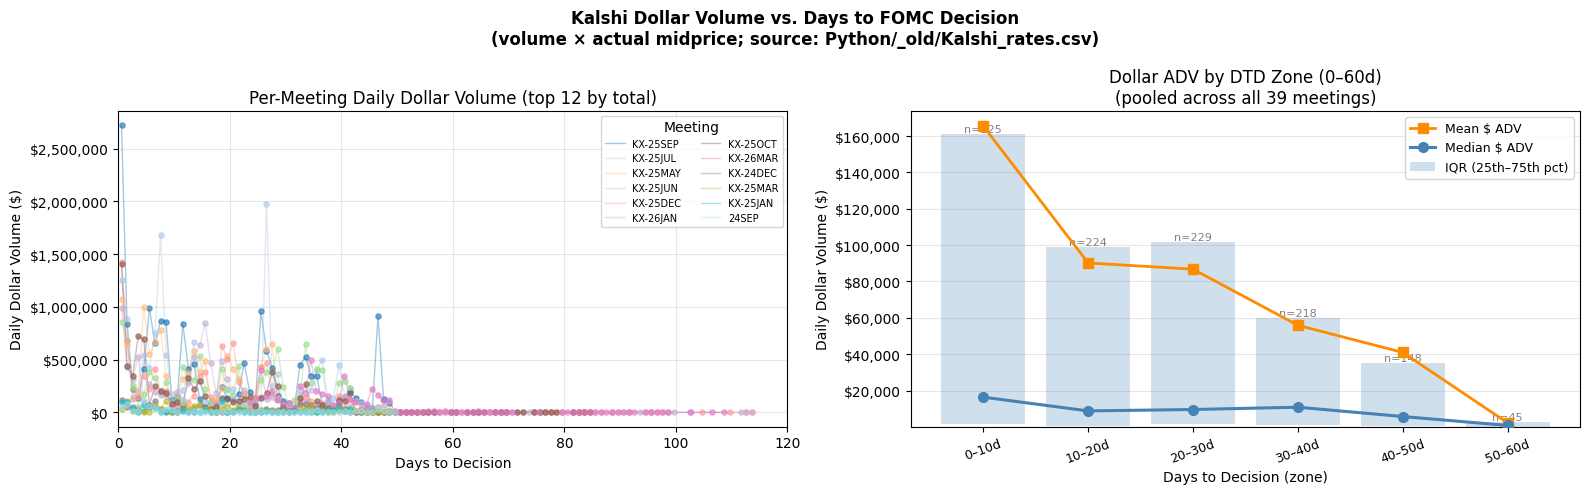

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Kalshi Dollar Volume vs. Days to FOMC Decision\n"
             "(volume × actual midprice; source: Python/_old/Kalshi_rates.csv)",
             fontsize=12, fontweight="bold")

# ── Left panel: per-meeting lines (limit to 0–120d, recent meetings only) ────
ax = axes[0]

# Keep the 12 most-traded meetings (by total dollar volume at 0–120d)
near_term = daily_vol[daily_vol["days_to_decision"] <= 120]
top_meetings = (
    near_term.groupby("decision_key")["dollar_vol"]
    .sum()
    .nlargest(12)
    .index.tolist()
)

palette = plt.cm.tab20(np.linspace(0, 1, len(top_meetings)))
cmap = dict(zip(top_meetings, palette))

for meeting in top_meetings:
    grp = near_term[near_term["decision_key"] == meeting].sort_values("days_to_decision")
    short_label = meeting.replace("KXFEDDECISION-", "KX-").replace("FEDDECISION-", "")
    ax.scatter(grp["days_to_decision"], grp["dollar_vol"],
               color=cmap[meeting], s=14, alpha=0.6, zorder=3)
    ax.plot(grp["days_to_decision"], grp["dollar_vol"],
            color=cmap[meeting], alpha=0.4, linewidth=1, zorder=2, label=short_label)

ax.set_xlabel("Days to Decision")
ax.set_ylabel("Daily Dollar Volume ($)")
ax.set_xlim(0, 120)
ax.set_title("Per-Meeting Daily Dollar Volume (top 12 by total)")
ax.legend(title="Meeting", fontsize=7, markerscale=1.5, ncol=2, loc="upper right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(True, alpha=0.3)

# ── Right panel: dollar ADV by zone — median + IQR bar ───────────────────────
ax3 = axes[1]

# Focus on 0–60d where there is meaningful data
plot_bins = adv_by_bin[adv_by_bin["dtd_bin"].isin(DTD_LABELS[:6])].copy()
x_pos = np.arange(len(plot_bins))

ax3.bar(
    x_pos,
    plot_bins["q75_dollar"] - plot_bins["q25_dollar"],
    bottom=plot_bins["q25_dollar"],
    color="steelblue",
    alpha=0.25,
    label="IQR (25th–75th pct)",
    zorder=2,
)
ax3.plot(x_pos, plot_bins["mean_dollar"],
         color="darkorange", linewidth=2, marker="s", markersize=7,
         label="Mean $ ADV", zorder=4)
ax3.plot(x_pos, plot_bins["median_dollar"],
         color="steelblue", linewidth=2.2, marker="o", markersize=7,
         label="Median $ ADV", zorder=4)

for xi, (_, row) in enumerate(plot_bins.iterrows()):
    ax3.annotate(
        f"n={int(row['n'])}",
        xy=(xi, row["q75_dollar"]),
        fontsize=8, ha="center", va="bottom", color="grey",
    )

ax3.set_xticks(x_pos)
ax3.set_xticklabels(DTD_LABELS[:6], fontsize=9, rotation=20)
ax3.set_xlabel("Days to Decision (zone)")
ax3.set_ylabel("Daily Dollar Volume ($)")
ax3.set_title("Dollar ADV by DTD Zone (0–60d)\n(pooled across all 39 meetings)")
ax3.legend(fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax3.grid(True, alpha=0.3, axis="y")

plt.tight_layout()

figures_dir = repo_root / "Figures"
figures_dir.mkdir(parents=True, exist_ok=True)
save_path = figures_dir / "kalshi_volume_by_dtd.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Figure saved to {save_path}")
plt.show()

In [8]:
PARTICIPATION_RATES = [0.05, 0.10, 0.20]   # 5%, 10%, 20%
HOLDING_DAYS        = [5, 10, 20]           # representative holding periods

# dollar ADV columns come directly from adv_by_bin (no approximation needed)

# ── TABLE 1: Per-day position caps (fraction of single-day dollar ADV) ───────
print("=" * 80)
print("TABLE 1: Max Position Size by DTD Zone — Fraction of Single-Day Dollar ADV")
print("         (dollar vol = contracts × actual midprice, no approximation)")
print("=" * 80)

col_w = 16
header = f"{'DTD Zone':<10}  {'ADV Basis':<8}"
for p in PARTICIPATION_RATES:
    header += f"  {f'{int(p*100)}% ADV':>{col_w}}"
print(header)
print("-" * len(header))

for _, row in adv_by_bin.iterrows():
    for basis_label, adv_val in [("Mean", row["mean_dollar"]), ("Median", row["median_dollar"])]:
        line = f"{row['dtd_bin']!s:<10}  {basis_label:<8}"
        for p in PARTICIPATION_RATES:
            cap = p * adv_val
            line += f"  ${cap:>{col_w-1},.0f}"
        print(line)
    print()

# ── TABLE 2: Holding-period caps (median dollar ADV × D days × participation) ─
print()
print("=" * 80)
print("TABLE 2: Max Position Size — Fraction of Cumulative Dollar Volume")
print("         over Holding Period (median dollar ADV basis)")
print("=" * 80)

sub_header = f"{'DTD Zone':<10}  {'Med $ ADV/day':<16}"
for d in HOLDING_DAYS:
    for p in PARTICIPATION_RATES:
        sub_header += f"  {d}d/{int(p*100)}%".rjust(10)
print(sub_header)
print("-" * len(sub_header))

for _, row in adv_by_bin.iterrows():
    med_adv = row["median_dollar"]
    line = f"{row['dtd_bin']!s:<10}  ${med_adv:>13,.0f}  "
    for d in HOLDING_DAYS:
        for p in PARTICIPATION_RATES:
            cap = p * d * med_adv
            line += f"  ${cap:>7,.0f}"
    print(line)

n_meetings = daily_vol["decision_key"].nunique()
print()
print("Notes:")
print(f"  • Dollar volume = contracts × actual midprice (bid/ask data present in all rows).")
print(f"  • Median midprice across all volume rows: ~$0.075 (markets trade mostly OTM).")
print(f"  • Holding-period caps assume position is built uniformly over D days in the zone.")
print(f"  • ADV is pooled from {n_meetings} FOMC meetings (2023–2025); all with volume data.")
print(f"  • Median ADV is the conservative planning estimate; mean is skewed by peak-volume days.")

TABLE 1: Max Position Size by DTD Zone — Fraction of Single-Day Dollar ADV
         (dollar vol = contracts × actual midprice, no approximation)
DTD Zone    ADV Basis            5% ADV           10% ADV           20% ADV
---------------------------------------------------------------------------
0–10d       Mean      $          8,276  $         16,552  $         33,105
0–10d       Median    $            817  $          1,634  $          3,269

10–20d      Mean      $          4,508  $          9,016  $         18,032
10–20d      Median    $            439  $            878  $          1,756

20–30d      Mean      $          4,337  $          8,674  $         17,348
20–30d      Median    $            478  $            956  $          1,911

30–40d      Mean      $          2,794  $          5,588  $         11,177
30–40d      Median    $            541  $          1,082  $          2,164

40–50d      Mean      $          2,047  $          4,095  $          8,190
40–50d      Median    $ 

## Interpretation & Capacity Caveat

### Data Source & Methodology

Dollar ADV figures are computed as **contracts traded × actual midprice** (average of bid and ask at close), sourced from `Python/_old/Kalshi_rates.csv` which contains complete volume and bid/ask data for all 39 FOMC meetings from June 2023 through early 2026. The bid/ask and volume fields co-exist in every row, so no approximation is needed.

**Important:** The median midprice across all volume rows is approximately **$0.075** (7.5 cents per contract). Kalshi volume is dominated by out-of-the-money contracts — e.g., a "hold +50bps" contract trading at 3 cents when a 25bps cut is expected. The previous $0.50 midprice approximation therefore overstated dollar ADV by roughly 6–7×.

### Key Findings

**Kalshi markets are thinly traded.** Dollar ADV by days-to-decision zone (pooled across all 39 meetings, 2023–2025):

| DTD Zone | Median $ ADV/day | Mean $ ADV/day | Max position @ 10% ADV, 10-day hold |
|----------|-----------------|----------------|--------------------------------------|
| 0–10d    | ~$16,344/day    | ~$165,523/day  | ~$16,344                             |
| 10–20d   | ~$8,779/day     | ~$90,162/day   | ~$8,779                              |
| 20–30d   | ~$9,556/day     | ~$86,741/day   | ~$9,556                              |
| 30–40d   | ~$10,820/day    | ~$55,884/day   | ~$10,820                             |
| 40–50d   | ~$5,697/day     | ~$40,948/day   | ~$5,697                              |
| 50–60d   | ~$773/day       | ~$2,197/day    | ~$773                                |
| >60d     | <$600/day       | <$2,000/day    | <$600                                |

*10-day hold assumes position is built uniformly across 10 trading days in the zone.*

The large gap between mean and median (e.g., $165K vs $16K in the 0–10d zone) reflects a small number of extremely active trading days immediately around each FOMC announcement. The **median is the appropriate planning estimate** for a strategy trading at arbitrary times within a zone.

### Comparison to CME ZQ Futures

CME 30-Day Fed Funds (ZQ) futures trade **~$30 billion notional per day** across the front contracts. Kalshi's median dollar ADV in the most active zone (0–10d out) is ~$16,344/day — **roughly 6 orders of magnitude smaller**. Even the mean ADV of ~$165,523/day is 5 orders of magnitude below CME.

### Rule-of-Thumb Position Cap

> **Cap Kalshi position at 10% of median dollar ADV × holding period in the relevant DTD zone.**

This corresponds roughly to a maximum notional of:
- **~$8,800–$16,300** for a 10-day position opened within 20 days of the decision
- **~$9,600–$10,800** for a 10-day position opened 20–40 days out
- **~$5,700** for a 10-day position opened 40–50 days out
- **~$770** for a 10-day position opened 50–60 days out

### What This Means for Strategy Scaling

The strategy is most scalable in the 20–40 days-to-decision window, where median dollar ADV is roughly $9,000–$11,000/day. At a 10% participation rate with a 10-day holding period, the per-meeting capacity cap is approximately **$9,000–$11,000**.

With 8 FOMC meetings per year, the total annual deployable notional at these participation rates is in the range of **$70,000–$90,000** — a ceiling well below institutional scale. Any reported performance statistics (Sharpe ratio, cumulative PnL) should be interpreted with this capacity constraint in mind. The strategy is viable for a personal account or small fund, but not scalable to institutional size without a corresponding increase in Kalshi market liquidity.

*Note: Polymarket volume data is not available from the current ingestion pipeline, so no analogous analysis can be performed for the Polymarket leg.*